In [1]:
# create a realistic ECG plot using Matplotlib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator


def plot_ecg_grid(
    min_time: float,
    max_time: float,
    min_ecg: float,
    max_ecg: float,
    alpha: float = 0.7,
):
    """Plot a classical ECG grid on the current Matplotlib axes."""
    if not 0.0 <= alpha <= 1.0:
        raise ValueError("alpha must be between 0.0 and 1.0.")
    if min_time >= max_time or min_ecg >= max_ecg:
        raise ValueError("Minimum values must be smaller than maximum values.")

    ax = plt.gca()
    ax.set_xlim(min_time, max_time)
    ax.set_ylim(min_ecg, max_ecg)

    ax.xaxis.set_major_locator(MultipleLocator(0.2))
    ax.xaxis.set_minor_locator(MultipleLocator(0.04))
    ax.yaxis.set_major_locator(MultipleLocator(0.5))
    ax.yaxis.set_minor_locator(MultipleLocator(0.1))
    ax.grid(which="minor", color="red", linewidth=0.4, alpha=alpha * 0.35)
    ax.grid(which="major", color="red", linewidth=0.8, alpha=alpha)


def plot_one_ecg_signal(time, ecg, lead_name: str, color: str):
    """Plot one ECG lead on the current Matplotlib axes."""
    time_values = np.asarray(time)
    ecg_values = np.asarray(ecg)

    if time_values.ndim != 1 or ecg_values.ndim != 1:
        raise ValueError("time and ecg must be one-dimensional arrays.")
    if len(time_values) != len(ecg_values):
        raise ValueError("time and ecg must have the same length.")

    ax = plt.gca()
    ax.plot(time_values, ecg_values, color=color, label=lead_name)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("ECG amplitude (mV)")
    ax.legend()
    return ax


def plot_one_lead_in_subplots(
    subplot: int,
    time,
    ecg,
    lead_name: str,
    color: str,
):
    """Plot one ECG lead on an ECG grid in one of three subplots."""
    if subplot not in (1, 2, 3):
        raise ValueError("subplot must be 1, 2, or 3.")

    time_values = np.asarray(time)
    ecg_values = np.asarray(ecg)

    if time_values.ndim != 1 or ecg_values.ndim != 1:
        raise ValueError("time and ecg must be one-dimensional arrays.")
    if len(time_values) != len(ecg_values) or len(time_values) == 0:
        raise ValueError("time and ecg must have the same non-empty length.")

    min_time = float(np.min(time_values))
    max_time = float(np.max(time_values))
    min_ecg = float(np.min(ecg_values))
    max_ecg = float(np.max(ecg_values))

    if min_time == max_time:
        max_time = min_time + 0.2
    if min_ecg == max_ecg:
        max_ecg = min_ecg + 0.5

    ax = plt.subplot(3, 1, subplot)
    plot_ecg_grid(min_time, max_time, min_ecg, max_ecg)
    ax.plot(time_values, ecg_values, color=color, label=lead_name, zorder=2)
    ax.set_title(lead_name)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("ECG amplitude (mV)")
    ax.legend()
    return ax


def plot_all_leads_in_subplots(time, ecg, lead_names: list[str], colors: list[str]):
    """Plot all ECG leads in separate subplots on ECG grids."""
    time_values = np.asarray(time)
    ecg_values = np.asarray(ecg)

    if time_values.ndim != 1:
        raise ValueError("time must be a one-dimensional array.")
    if ecg_values.ndim != 2:
        raise ValueError("ecg must be a two-dimensional array.")
    if ecg_values.shape[0] != len(time_values):
        raise ValueError("ecg must have one row for each time value.")

    number_of_leads = ecg_values.shape[1]
    if len(lead_names) != number_of_leads or len(colors) != number_of_leads:
        raise ValueError("lead_names and colors must match the number of ECG leads.")
    if number_of_leads == 0:
        raise ValueError("ecg must contain at least one lead.")

    figure, axes = plt.subplots(number_of_leads, 1, sharex=True, squeeze=False)
    axes = axes[:, 0]

    for index, ax in enumerate(axes):
        lead_values = ecg_values[:, index]
        min_time = float(np.min(time_values))
        max_time = float(np.max(time_values))
        min_ecg = float(np.min(lead_values))
        max_ecg = float(np.max(lead_values))

        if min_time == max_time:
            max_time = min_time + 0.2
        if min_ecg == max_ecg:
            max_ecg = min_ecg + 0.5

        plt.sca(ax)
        plot_ecg_grid(min_time, max_time, min_ecg, max_ecg)
        ax.plot(time_values, lead_values, color=colors[index], label=lead_names[index], zorder=2)
        ax.set_title(lead_names[index])
        ax.set_ylabel("ECG amplitude (mV)")
        ax.legend()

    axes[-1].set_xlabel("Time (s)")
    figure.tight_layout()
    return figure, axes


In [2]:
#Load the data into a numpy array
ecg = np.loadtxt("ECGu.txt")

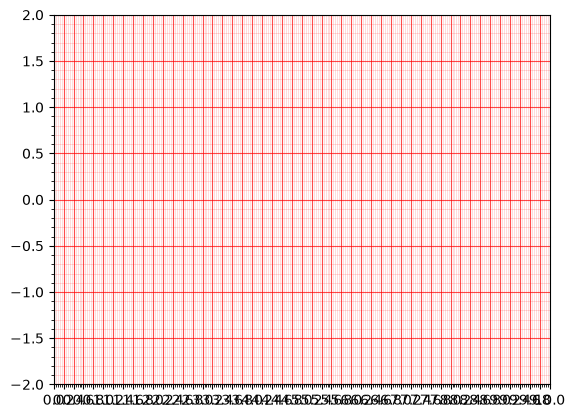

In [3]:
plot_ecg_grid(
    min_time=0,
    max_time=10,
    min_ecg=-2,
    max_ecg=2,
)

Locator attempting to generate 3679 ticks ([-632.5, ..., 1206.5]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 18383 ticks ([-632.1, ..., 1206.1]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 3679 ticks ([-632.5, ..., 1206.5]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 3679 ticks ([-632.5, ..., 1206.5]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 18383 ticks ([-632.1, ..., 1206.1]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 3679 ticks ([-632.5, ..., 1206.5]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 3679 ticks ([-632.5, ..., 1206.5]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 18383 ticks ([-632.1, ..., 1206.1]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 3679 ticks ([-632.5, ..., 1206.5]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 3679 ticks (

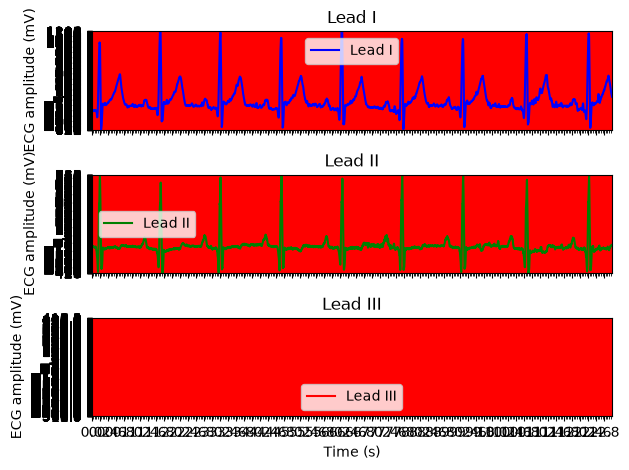

In [5]:
# Plot the three ECG leads
sampling_frequency = 500  # Change this if the data uses another frequency in Hz
time = np.arange(ecg.shape[0]) / sampling_frequency

plot_all_leads_in_subplots(
    time=time,
    ecg=ecg,
    lead_names=["Lead I", "Lead II", "Lead III"],
    colors=["blue", "green", "red"],
)

plt.show()
